In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

# Set Chinese font and style
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['axes.edgecolor'] = 'black'   # Spine color
plt.rcParams['axes.linewidth'] = 1.0       # Spine width
plt.rcParams['axes.grid'] = False        # Master switch

In [2]:
# 1. Load data
df = pd.read_csv('csv/df_k.csv')

# 2. Only take data with k < 20
df_filtered = df[df['k(W/mK)'] < 10].copy()
print(f"Original data count: {len(df)}")
print(f"Filtered data count (k < 10): {len(df_filtered)}")

# 3. Prepare data
X = df_filtered.drop(columns=['k(W/mK)', 'formula', 'composition'])
y = df_filtered['k(W/mK)']

print(f"Feature count: {X.shape[1]}")
print(f"Target variable range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Target variable mean: {y.mean():.2f}")

# 4. Missing value handling
print(f'Feature missing values count: {X.isnull().sum().sum()}')
print(f'Target variable missing values count: {y.isnull().sum()}')

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())
if y.isnull().sum() > 0:
    y = y.fillna(y.mean())

# 5. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')

# 6. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Original data count: 1003
Filtered data count (k < 10): 970
Feature count: 133
Target variable range: [0.20, 9.93]
Target variable mean: 3.02
Feature missing values count: 0
Target variable missing values count: 0
Training set size: (776, 133)
Testing set size: (194, 133)


In [3]:
# 7. Create XGBoost regression model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# 8. Train model
xgb_model.fit(X_train_scaled, y_train)

# 9. Predict
y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred  = xgb_model.predict(X_test_scaled)

# 10. Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test, y_test_pred)
mae        = mean_absolute_error(y_test, y_test_pred)

print(f'Training set RMSE: {train_rmse:.3f}')
print(f'Testing set RMSE: {test_rmse:.3f}')
print(f'Training set R²: {train_r2:.3f}')
print(f'Testing set R²: {test_r2:.3f}')
print(f'Testing set MAE: {mae:.3f}')

Training set RMSE: 0.381
Testing set RMSE: 0.725
Training set R²: 0.971
Testing set R²: 0.897
Testing set MAE: 0.483


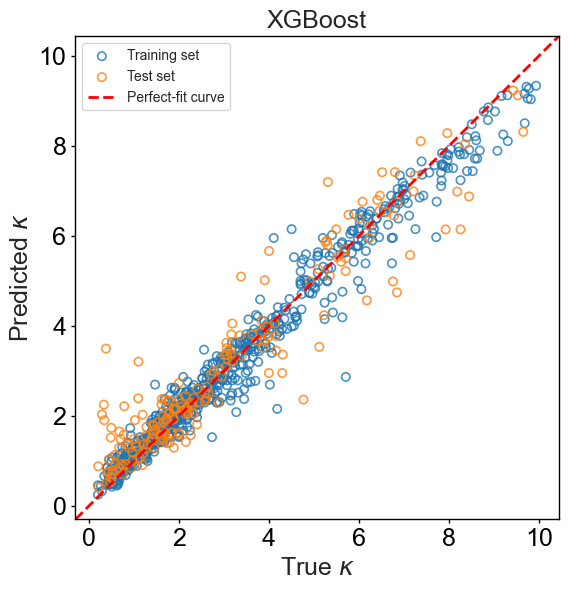

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.tick_params(axis='both',          # Operate on both x and y axes
               which='major',        # Major ticks (minor ticks similarly)
               direction='out',       # Ticks inward, out/both also possible
               length=3,             # Tick length
               width=1.0,            # Tick width
               colors='black')       # Tick color

# 1. Training set: hollow blue circles
ax.scatter(y_train, y_train_pred,
           facecolors='none',          # Hollow
           edgecolors='tab:blue',
           linewidth=1.2,
           alpha=0.8,
           label='Training set')

# 2. Test set: hollow orange circles
ax.scatter(y_test, y_test_pred,
           facecolors='none',
           edgecolors='tab:orange',
           linewidth=1.2,
           alpha=0.8,
           label='Test set')

# 3. Perfect fit line
lim = [y.min() - 0.5, y.max() + 0.5]
ax.plot(lim, lim, 'r--', lw=2, label='Perfect-fit curve')

# 4. Other styling
ax.set_xlabel(r'True $\kappa$', fontsize=18)
ax.set_ylabel(r'Predicted $\kappa$', fontsize=18)
ax.set_title('XGBoost', fontsize=18)  # Only change title here
ax.legend()

# # 5. Metric text (upper right corner)
# text_str = (f'Train RMSE = {train_rmse:.3f}\n'
#             f'Train R² = {train_r2:.3f}\n'
#             f'Test RMSE = {test_rmse:.3f}\n'
#             f'Test R² = {test_r2:.3f}')
# ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
#         fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 6. Equal aspect ratio axes
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')

# 7. Show tick marks
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=18)

plt.tight_layout()
plt.savefig('png/XGB.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
from sklearn.model_selection import cross_val_score

# 1. Get feature importance and sort
feat_imp = xgb_model.feature_importances_
cols = X.columns
imp_df = pd.DataFrame({'feature': cols, 'importance': feat_imp})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# 2. Gradually increase features, record CV R²
n_feat = len(imp_df)
r2_mean, r2_std = [], []

for k in range(1, n_feat + 1):
    top_k_cols = imp_df['feature'].head(k).values
    X_k = X_train_scaled[:, [list(cols).index(c) for c in top_k_cols]]

    # Create a new XGB model (avoid contaminating previous one)
    model_k = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(model_k, X_k, y_train,
                             cv=5, scoring='r2')
    r2_mean.append(scores.mean())
    r2_std.append(scores.std())

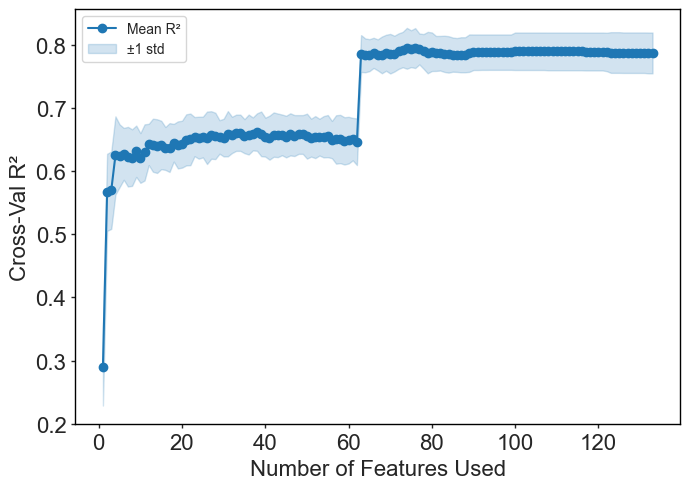

In [6]:
# 3. Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=16)
x = np.arange(1, n_feat + 1)
ax.plot(x, r2_mean, 'o-', color='tab:blue', label='Mean R²')
ax.fill_between(x,
                np.array(r2_mean) - np.array(r2_std),
                np.array(r2_mean) + np.array(r2_std),
                color='tab:blue', alpha=0.2, label='±1 std')
ax.set_xlabel('Number of Features Used', fontsize=16)
ax.set_ylabel('Cross-Val R²', fontsize=16)
#ax.set_title('XGB: CV R² vs Number of Features')
ax.legend()
plt.tight_layout()
plt.savefig('png/CV=5.png', dpi=100, bbox_inches='tight')
plt.show()

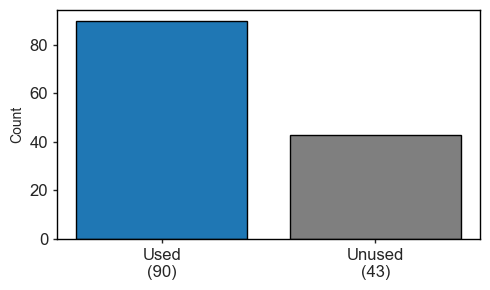

In [7]:
# 1. Count non-zero importance features
used_mask = feat_imp > 0
n_used = used_mask.sum()
n_zero = len(feat_imp) - n_used

# 2. Plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=12)       # Tick color
labels = [f'Used\n({n_used})', f'Unused\n({n_zero})']
counts = [n_used, n_zero]
colors = ['tab:blue', 'tab:gray']

bars = ax.bar(labels, counts, color=colors, edgecolor='black')
#ax.set_title('XGB: Number of Features Used vs Unused')
ax.set_ylabel('Count')
# # Display numbers on bars
# for bar, c in zip(bars, counts):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
#             str(c), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('png/Used-un.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
def short_name(s):
    # 1. Remove MagpieData prefix and spaces
    s = re.sub(r'^MagpieData\s+', '', s)

    # 2. Split string to get statistic type and property name
    parts = s.split()
    if len(parts) >= 2:
        stat_type = parts[0]  # Statistic type: maximum, minimum, mean, avg_dev, etc.
        prop_name = ' '.join(parts[1:])  # Property name

        # 3. Convert statistic type to abbreviation
        if stat_type == 'maximum':
            stat_abbr = 'max'
        elif stat_type == 'minimum':
            stat_abbr = 'min'
        elif stat_type == 'avg_dev':
            stat_abbr = 'avg_dev'  # Keep unchanged
        elif stat_type == 'mean':
            stat_abbr = 'mean'  # Keep unchanged
        else:
            stat_abbr = stat_type  # Keep other types unchanged

        # 4. Process property name: take first two letters + last letter
        # Remove spaces and underscores from property name
        clean_prop = prop_name.replace(' ', '').replace('_', '')

        if len(clean_prop) >= 3:
            # Take first two letters + last letter
            prop_abbr = clean_prop[:2] + clean_prop[-1]
        else:
            # If property name is too short, use as is
            prop_abbr = clean_prop

        # 5. Combine result: statistic abbreviation_property abbreviation
        return f"{stat_abbr}_{prop_abbr}"
    else:
        # If no space separation, process directly
        if len(s) > 10:
            return s[:10] + '…'
        return s

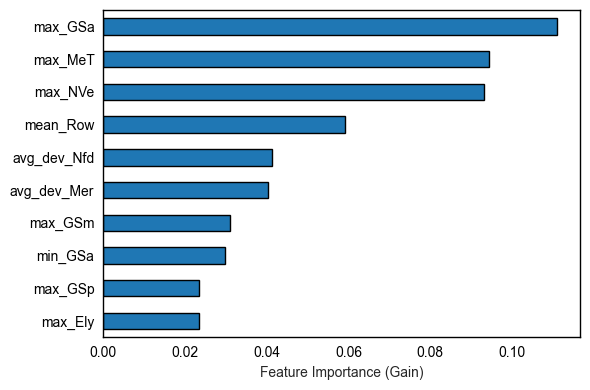

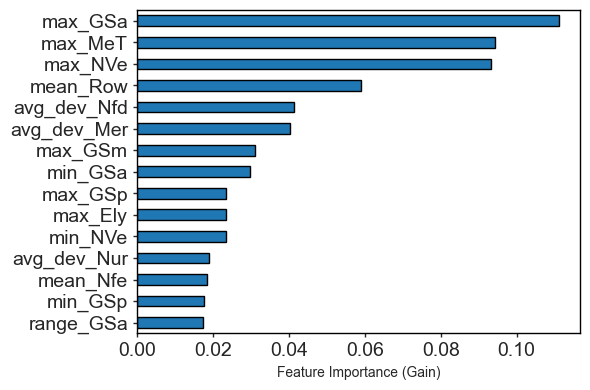

In [9]:
# 1. Extract importance and sort
imp = xgb_model.feature_importances_
feat_imp = pd.Series(imp, index=X.columns).sort_values(ascending=False)

# 0. First ensure we have top10 original column names
top10_orig = feat_imp.head(10).index          # Length =10

# 1. Generate abbreviation mapping (only calculate for these 10 to save time)
short_map = {col: short_name(col) for col in top10_orig}
# If thermal conductivity is inside, manually override with latex symbol
short_map['k(W/mK)'] = r'$\kappa$'

# 2. Replace Series index with abbreviations at once
top10_short = feat_imp.head(10).rename(index=short_map)

# 3. Plot
plt.figure(figsize=(6, 4))
ax = top10_short.sort_values().plot(kind='barh',      # Sort first, most important on top
                                    color='tab:blue',
                                    edgecolor='black')
ax.tick_params(axis='both',
               which='major',
               direction='out',
               length=3,
               width=1.0,
               colors='black')
plt.xlabel('Feature Importance (Gain)')
#plt.title('XGBoost Top 10 Features')
plt.tight_layout()
#plt.savefig('../png/Top10Features.png', dpi=300, bbox_inches='tight')
plt.show()

# 1. Take top 15 and replace long names with abbreviations
top15_orig = feat_imp.head(15).index          # 15 original column names
short_map  = {col: short_name(col) for col in top15_orig}
short_map['k(W/mK)'] = r'$\kappa$'       # Manually override thermal conductivity

top15_short = feat_imp.head(15).rename(index=short_map)

# 2. Plot
plt.figure(figsize=(6, 4))
ax = top15_short.sort_values().plot(kind='barh',
                                    color='tab:blue',
                                    edgecolor='black')
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=14)
plt.xlabel('Feature Importance (Gain)')
#plt.title('XGBoost Top 15 Features')
plt.tight_layout()
plt.savefig('png/Top15Features.png', dpi=100, bbox_inches='tight')
plt.show()

### Prediction Phase

In [10]:
# 1. 保存模型
joblib.dump(xgb_model, 'model/xgb_k_model.pkl')

# 2. 保存标准化器（StandardScaler）
joblib.dump(scaler, 'model/scaler.pkl')

# 3. 保存特征顺序（防止新数据列顺序乱）
joblib.dump(X_train.columns.tolist(), 'model/feature_order.pkl')

['model/feature_order.pkl']

In [11]:
# 1. Load three essential components
model = joblib.load('model/xgb_k_model.pkl')
scaler = joblib.load('model/scaler.pkl')
feat_order = joblib.load('model/feature_order.pkl')  # Column order during training

In [12]:
# 2. Read new data (without k)
new_df = pd.read_csv('csv/new_magpie.csv')

# 3. Align columns & missing values
X_new = new_df[feat_order]          # Slice according to training order
X_new = X_new.fillna(X_new.mean())  # Consistent with training

# 4. Standardize
X_new_scaled = scaler.transform(X_new)

# 5. Predict
kl_pred = model.predict(X_new_scaled)

In [13]:
def short_name(s):
    """Function you provided, no changes needed"""
    s = re.sub(r'^MagpieData\s+', '', s)
    parts = s.split()
    if len(parts) >= 2:
        stat_type, prop_name = parts[0], ' '.join(parts[1:])
        stat_abbr = {'maximum':'max', 'minimum':'min',
                     'avg_dev':'avg_dev', 'mean':'mean'}.get(stat_type, stat_type)
        clean_prop = prop_name.replace(' ', '').replace('_', '')
        prop_abbr = clean_prop[:2] + clean_prop[-1] if len(clean_prop) >= 3 else clean_prop
        return f"{stat_abbr}_{prop_abbr}"
    return (s[:10] + '…') if len(s) > 10 else s

# 1. Extract original long names
long_names = scaler.get_feature_names_out()   # or scaler.feature_names_in_

# 2. Generate short names
short_names = [short_name(n) for n in long_names]

# 3. Assemble into DataFrame, column names are simplified feature names
X_new_df = pd.DataFrame(X_new_scaled, columns=short_names)

# # 4. View results
# print(X_new_df.head())

In [14]:
# ---------- 1. Create long name to short name mapping ----------
name_map = {ln: sn for ln, sn in zip(long_names, short_names)}

# ---------- 2. Given 10 "symmetric" intervals ----------
intervals = {
    'max_GSa'     : [ -0.888,   4.628],
    'max_MeT'     : [ -2.011,   0.188],
    'max_NVe'     : [  0.035,   1.908],
    'mean_Row'    : [ -0.855,   2.260],
    'avg_dev_Nfd' : [ -0.228,   6.408],
    'avg_dev_Mer' : [ -0.088,   1.712],
    'max_GSm'     : [ -0.513,  -0.513],
    'min_GSa'     : [ -0.422,   3.008],
}

# ---------- 3. Statistics + Print ----------
df = pd.DataFrame(X_new_scaled, columns=short_names)

for short, (lo, hi) in intervals.items():
    # Find corresponding column
    if short not in df.columns:
        print(f'{short:20s}: Not found in current features')
        continue
    col = df[short]
    n_inside = col.between(lo, hi).sum()
    print(f'{short:20s}: [{lo:7.3f}, {hi:7.3f}] → {n_inside}')

max_GSa             : [ -0.888,   4.628] → 397
max_MeT             : [ -2.011,   0.188] → 325
max_NVe             : [  0.035,   1.908] → 73
mean_Row            : [ -0.855,   2.260] → 396
avg_dev_Nfd         : [ -0.228,   6.408] → 414
avg_dev_Mer         : [ -0.088,   1.712] → 123
max_GSm             : [ -0.513,  -0.513] → 0
min_GSa             : [ -0.422,   3.008] → 412


In [15]:
# ---------- 1. Create long name to short name mapping ----------
name_map = {ln: sn for ln, sn in zip(long_names, short_names)}

# ---------- 2. Given 10 "symmetric" intervals ----------
intervals = {
    'max_GSa'     : [ -0.888,   4.628],
    'max_MeT'     : [ -2.011,   0.188],
    'max_NVe'     : [  0.035,   1.908],
    'mean_Row'    : [ -0.855,   2.260],
    'avg_dev_Nfd' : [ -0.228,   6.408],
    'avg_dev_Mer' : [ -0.088,   1.712],
    'max_GSm'     : [ -0.513,  -0.513],
    'min_GSa'     : [ -0.422,   3.008],
}

# ---------- 3. Statistics + Print ----------
df = pd.DataFrame(X_new_scaled, columns=short_names)

# Store sample IDs for each interval
interval_samples = {}

for short, (lo, hi) in intervals.items():
    # Find corresponding column
    if short not in df.columns:
        print(f'{short:20s}: Not found in current features')
        continue

    col = df[short]
    # Find sample indices within interval
    mask = col.between(lo, hi)
    n_inside = mask.sum()

    # Get sample IDs
    sample_ids = df[mask].index.tolist()

    # Store results
    interval_samples[short] = sample_ids

    # Print results
    print(f'{short:20s}: [{lo:7.3f}, {hi:7.3f}] → {n_inside} samples')

    # If sample count is small, display specific sample IDs
    if n_inside <= 10:
        if n_inside > 0:
            print(f'     Sample IDs: {sample_ids}')
    else:
        # If too many samples, only show first 10
        print(f'     First 10 sample IDs: {sample_ids[:10]}...')
        print(f'     (Total {n_inside} samples)')
    print('-' * 50)

# ---------- 4. Check which intervals each sample hits ----------
print('\n' + '='*80)
print('Interval hit statistics for each sample:')
print('='*80)

# Create a dictionary to store intervals hit by each sample
sample_hits = {}

# Iterate through each interval, add samples to corresponding sets
for short, sample_list in interval_samples.items():
    for sample_id in sample_list:
        if sample_id not in sample_hits:
            sample_hits[sample_id] = []
        sample_hits[sample_id].append(short)

# Count distribution of hit counts
hit_count_dist = {}
for sample_id, intervals_list in sample_hits.items():
    hit_count = len(intervals_list)
    if hit_count not in hit_count_dist:
        hit_count_dist[hit_count] = []
    hit_count_dist[hit_count].append(sample_id)

# Print hit distribution
print(f'\nHit count distribution:')
for count in sorted(hit_count_dist.keys()):
    samples = hit_count_dist[count]
    print(f'  Hit {count} intervals: {len(samples)} samples')

# Print samples with most interval hits
print(f'\nSamples with most interval hits (top 20):')
sorted_samples = sorted(sample_hits.items(), key=lambda x: len(x[1]), reverse=True)

for i, (sample_id, intervals_list) in enumerate(sorted_samples[:50]):
    print(f'  Sample {sample_id:4d}: hit {len(intervals_list):2d} intervals → {intervals_list}')

# ---------- 5. Create result DataFrame ----------
# Create DataFrame containing hit information for each sample
hit_data = []
for sample_id in range(len(df)):
    if sample_id in sample_hits:
        hit_features = sample_hits[sample_id]
    else:
        hit_features = []

    hit_data.append({
        'sample_id': sample_id,
        'n_intervals_hit': len(hit_features),
        'hit_features': hit_features
    })

hit_df = pd.DataFrame(hit_data)
print(f'\nHit status for first 50 samples:')
print(hit_df.head(50))

max_GSa             : [ -0.888,   4.628] → 397 samples
     First 10 sample IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
     (Total 397 samples)
--------------------------------------------------
max_MeT             : [ -2.011,   0.188] → 325 samples
     First 10 sample IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
     (Total 325 samples)
--------------------------------------------------
max_NVe             : [  0.035,   1.908] → 73 samples
     First 10 sample IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
     (Total 73 samples)
--------------------------------------------------
mean_Row            : [ -0.855,   2.260] → 396 samples
     First 10 sample IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
     (Total 396 samples)
--------------------------------------------------
avg_dev_Nfd         : [ -0.228,   6.408] → 414 samples
     First 10 sample IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
     (Total 414 samples)
--------------------------------------------------
avg_dev_Mer         : [ -0.088,   1.712] → 123 

In [16]:
# ---------- 1. Construct (n_sample, 10) boolean matrix ----------
# First extract lower and upper bounds in intervals order
intv_order = list(intervals.keys())          # Fixed order
lows  = np.array([intervals[k][0] for k in intv_order])
highs = np.array([intervals[k][1] for k in intv_order])

# Corresponding column positions in DataFrame
idx_map = {fn: short_names.index(fn) for fn in intv_order}

# Extract these 10 column feature values
X10 = X_new_scaled[:, [idx_map[fn] for fn in intv_order]]  # shape (n_samples, 10)

# Single broadcast comparison
hit_mat = (X10 >= lows) & (X10 <= highs)   # Boolean matrix, True=fall into corresponding interval

# ---------- 2. How many intervals each sample hits ----------
hits_per_sample = hit_mat.sum(axis=1)      # shape (n_samples,)

# ---------- 3. View results ----------
hit_df = pd.DataFrame({
    'sample_id': np.arange(len(hits_per_sample)),
    'n_intervals_hit': hits_per_sample
})

print(hit_df.head(50))                       # First 50 samples

    sample_id  n_intervals_hit
0           0                6
1           1                6
2           2                6
3           3                6
4           4                6
5           5                6
6           6                6
7           7                6
8           8                6
9           9                6
10         10                6
11         11                6
12         12                6
13         13                6
14         14                6
15         15                6
16         16                6
17         17                6
18         18                6
19         19                6
20         20                6
21         21                6
22         22                6
23         23                6
24         24                3
25         25                6
26         26                6
27         27                5
28         28                5
29         29                5
30         30                5
31      

In [17]:
# ---------- 1. Construct (n_sample, 10) boolean matrix ----------
# First extract lower and upper bounds in intervals order
intv_order = list(intervals.keys())          # Fixed order
lows  = np.array([intervals[k][0] for k in intv_order])
highs = np.array([intervals[k][1] for k in intv_order])

# Corresponding column positions in DataFrame
idx_map = {fn: short_names.index(fn) for fn in intv_order}

# Extract these 10 column feature values
X10 = X_new_scaled[:, [idx_map[fn] for fn in intv_order]]  # shape (n_samples, 10)

# Single broadcast comparison
hit_mat = (X10 >= lows) & (X10 <= highs)   # Boolean matrix, True=fall into corresponding interval

# ---------- 2. How many intervals each sample hits ----------
hits_per_sample = hit_mat.sum(axis=1)      # shape (n_samples,)

# ---------- 3. Get specific feature names hit by each sample ----------
hit_features_per_sample = []

for i in range(len(hits_per_sample)):
    # Find feature indices hit by this sample
    hit_indices = np.where(hit_mat[i])[0]
    # Convert indices to feature names
    hit_features = [intv_order[idx] for idx in hit_indices]
    hit_features_per_sample.append(hit_features)

# ---------- 4. Create result DataFrame ----------
hit_df = pd.DataFrame({
    'sample_id': np.arange(len(hits_per_sample)),
    'n_intervals_hit': hits_per_sample,
    'hit_features': hit_features_per_sample
})

print("Hit status for first 50 samples:")
print(hit_df.head(50))

Hit status for first 50 samples:
    sample_id  n_intervals_hit  \
0           0                6   
1           1                6   
2           2                6   
3           3                6   
4           4                6   
5           5                6   
6           6                6   
7           7                6   
8           8                6   
9           9                6   
10         10                6   
11         11                6   
12         12                6   
13         13                6   
14         14                6   
15         15                6   
16         16                6   
17         17                6   
18         18                6   
19         19                6   
20         20                6   
21         21                6   
22         22                6   
23         23                6   
24         24                3   
25         25                6   
26         26                6   
27         27  

In [18]:
# 6. Save results
new_df['pred_k(W/mK)'] = kl_pred
new_df.to_csv('csv/xgb_new.csv', index=False)

### New Data

In [19]:
# Read data
data = pd.read_csv('csv/new_k.csv')

# Extract true and predicted values
true_vals = data['true_k(W/mK)'].values
pred_vals = data['pred_k(W/mK)'].values

# Calculate R²
r2 = r2_score(true_vals, pred_vals)

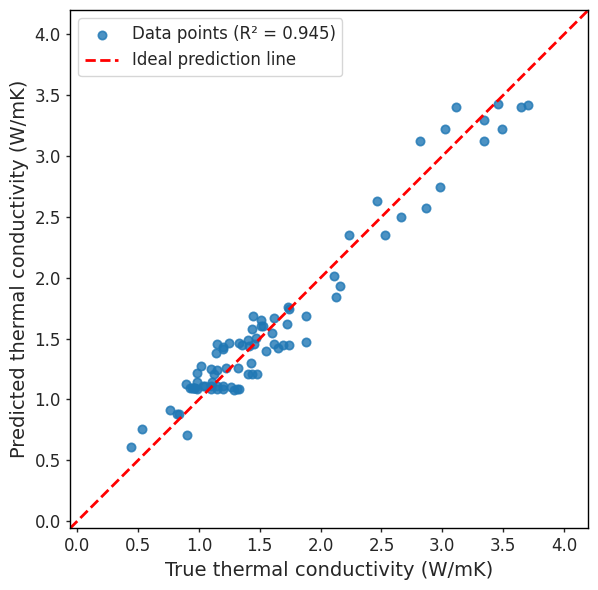

Coefficient of determination R² = 0.9450


In [20]:
# Configure matplotlib settings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scatter plot
ax.scatter(true_vals, pred_vals,
           facecolors='tab:blue',   # Key for hollow
           edgecolors='tab:blue',
           linewidth=1.2,
           alpha=0.8,
           label=f'Data points (R² = {r2:.3f})')

# Plot diagonal line y=x
lim = [min(true_vals.min(), pred_vals.min()) - 0.5, max(true_vals.max(), pred_vals.max()) + 0.5]
ax.plot(lim, lim, 'r--', lw=2, label='Ideal prediction line')

# Add labels and title
ax.set_xlabel('True thermal conductivity (W/mK)', fontsize=14)
ax.set_ylabel('Predicted thermal conductivity (W/mK)', fontsize=14)
#ax.set_title('Predicted vs True Thermal Conductivity', fontsize=14, fontweight='bold')

# Add legend
ax.legend(fontsize=12)

# Set equal aspect ratio axes
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')

# Set tick marks
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=12)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('png/new.png', dpi=100, bbox_inches='tight')

# Display figure
plt.show()

print(f'Coefficient of determination R² = {r2:.4f}')